In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import datetime as dt
import yfinance as yf
import warnings
warnings.filterwarnings("ignore")
pd.options.display.float_format = '{:.4%}'.format

In [2]:
# Date range
now = dt.datetime.now() - dt.timedelta(days=1)
start = now - dt.timedelta(days=365*3)
start = start.strftime('%Y-%m-%d')

# Tickers of assets
assets = ["SPY", "QQQM", "277630.KS", "272910.KS", "IMTB"]
assets.sort()
# Downloading data
data = yf.download(assets, start = start, end = now)
data = data.loc[:,('Close', slice(None))]
data.columns = assets

[*********************100%***********************]  5 of 5 completed


In [3]:
# Calculating returns
Y = data[assets].pct_change().dropna()
display(Y.head())

,272910.KS,277630.KS,IMTB,QQQM,SPY
Date,,,,,
2022-09-02,0.1010%,-0.2211%,0.5811%,-1.3477%,-1.0544%
2022-09-05,0.4091%,-0.2418%,0.0000%,0.0000%,0.0000%
2022-09-06,-0.0741%,0.2222%,-0.8599%,-0.7407%,-0.3773%
2022-09-07,-0.1112%,-1.4309%,0.4781%,1.9899%,1.7965%
2022-09-08,0.3074%,0.2658%,-0.0793%,0.4959%,0.6536%


In [4]:
import riskfolio as rp

# Building the portfolio object
port = rp.Portfolio(returns=Y)

# Calculating optimal portfolio

# Select method and estimate input parameters:

method_mu='hist' # Method to estimate expected returns based on historical data.
method_cov='hist' # Method to estimate covariance matrix based on historical data.

port.assets_stats(method_mu=method_mu, method_cov=method_cov)

# Estimate optimal portfolio:

model='Classic' # Could be Classic (historical), BL (Black Litterman) or FM (Factor Model)
rm = 'MV' # Risk measure used, this time will be variance
obj = 'Sharpe' # Objective function, could be MinRisk, MaxRet, Utility or Sharpe
hist = True # Use historical scenarios for risk measures that depend on scenarios
rf = 0 # Risk free rate
l = 0 # Risk aversion factor, only useful when obj is 'Utility'

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,272910.KS,277630.KS,IMTB,QQQM,SPY
weights,87.8803%,2.8421%,1.9264%,4.7165%,2.6346%


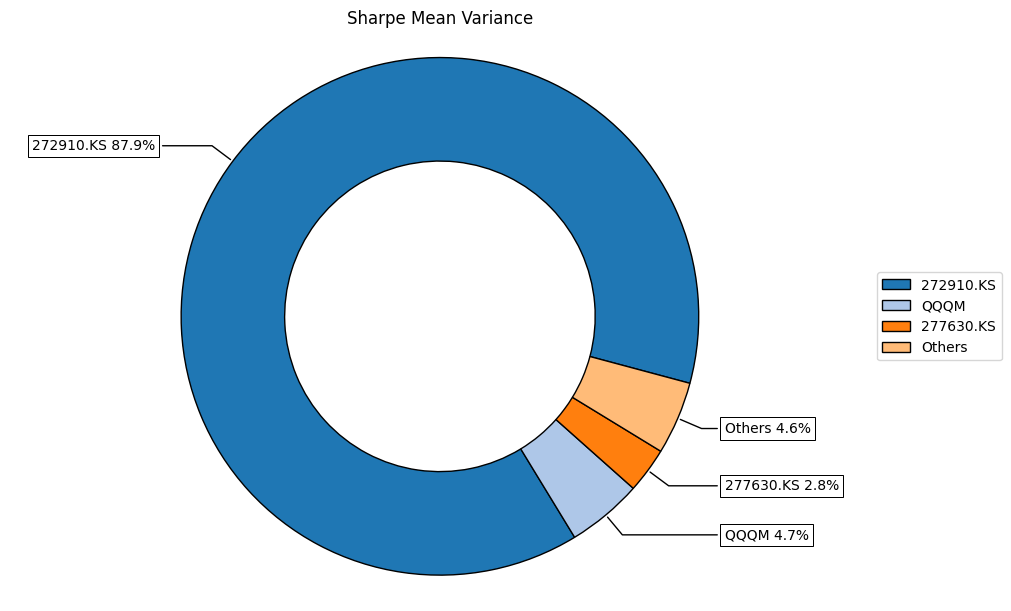

In [5]:
# Plotting the composition of the portfolio

ax = rp.plot_pie(w=w, title='Sharpe Mean Variance', others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

In [6]:
points = 10 # Number of points of the frontier

frontier = port.efficient_frontier(model=model, rm=rm, points=points, rf=rf, hist=hist)

display(frontier.T.head())

,272910.KS,277630.KS,IMTB,QQQM,SPY
0,90.3166%,0.0000%,8.4218%,0.0000%,1.2615%
1,73.9941%,8.6992%,0.0000%,17.3065%,0.0002%
2,58.6535%,14.2514%,0.0000%,27.0950%,0.0001%
3,44.2956%,19.4479%,0.0000%,36.2564%,0.0000%
4,30.3034%,24.5097%,0.0000%,45.1869%,0.0000%


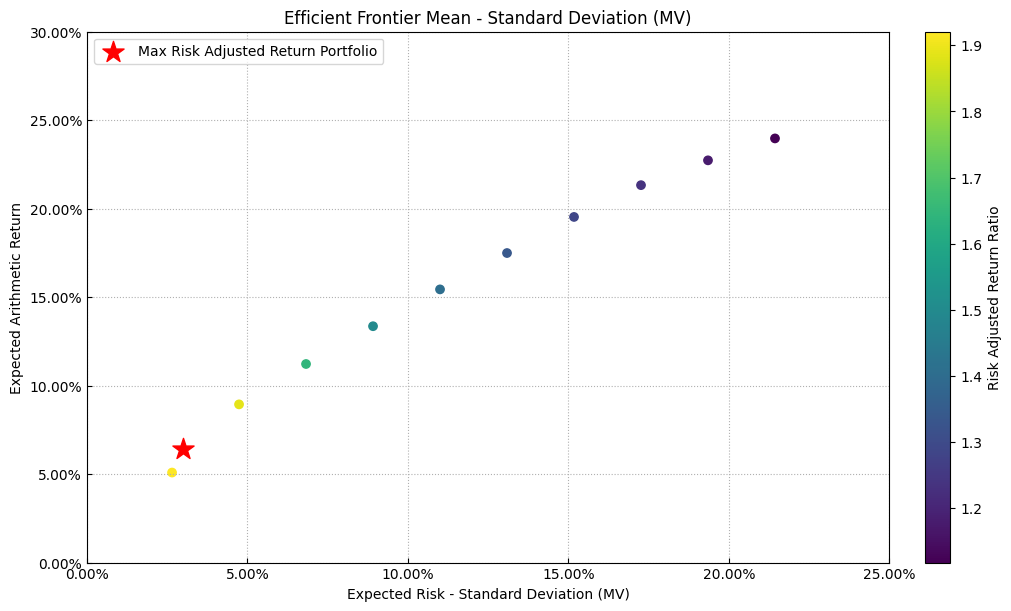

In [7]:
label = 'Max Risk Adjusted Return Portfolio' # Title of point
mu = port.mu # Expected returns
cov = port.cov # Covariance matrix
returns = port.returns # Returns of the assets

ax = rp.plot_frontier(w_frontier=frontier, mu=mu, cov=cov, returns=returns, rm=rm,
                      rf=rf, alpha=0.05, cmap='viridis', w=w, label=label,
                      marker='*', s=16, c='r', height=6, width=10, ax=None)

In [8]:
rm = 'CVaR' # Risk measure

w = port.optimization(model=model, rm=rm, obj=obj, rf=rf, l=l, hist=hist)

display(w.T)

,272910.KS,277630.KS,IMTB,QQQM,SPY
weights,82.6934%,3.9848%,4.5298%,7.2369%,1.5551%


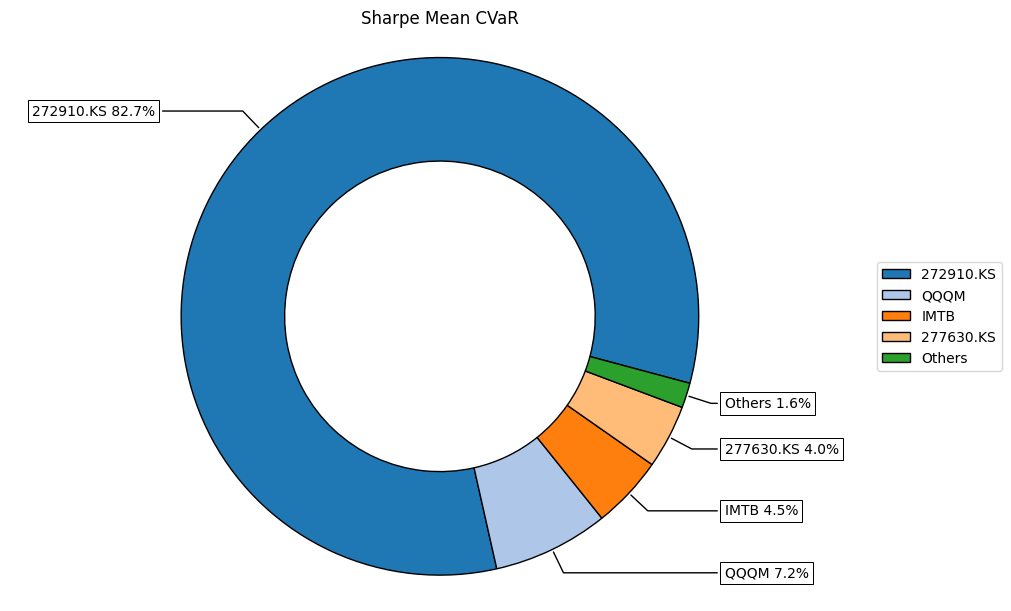

In [9]:
ax = rp.plot_pie(w=w, title='Sharpe Mean CVaR', others=0.05, nrow=25, cmap = "tab20",
                 height=6, width=10, ax=None)

In [10]:
# Risk Measures available:
#
# 'MV': Standard Deviation.
# 'MAD': Mean Absolute Deviation.
# 'MSV': Semi Standard Deviation.
# 'FLPM': First Lower Partial Moment (Omega Ratio).
# 'SLPM': Second Lower Partial Moment (Sortino Ratio).
# 'CVaR': Conditional Value at Risk.
# 'EVaR': Entropic Value at Risk.
# 'WR': Worst Realization (Minimax)
# 'MDD': Maximum Drawdown of uncompounded cumulative returns (Calmar Ratio).
# 'ADD': Average Drawdown of uncompounded cumulative returns.
# 'CDaR': Conditional Drawdown at Risk of uncompounded cumulative returns.
# 'EDaR': Entropic Drawdown at Risk of uncompounded cumulative returns.
# 'UCI': Ulcer Index of uncompounded cumulative returns.
rms = ['MV', 'MAD', 'MSV', 'FLPM', 'SLPM', 'CVaR',
       'EVaR', 'WR', 'MDD', 'ADD', 'CDaR', 'UCI', 'EDaR']

w_s = pd.DataFrame([])

for i in rms:
    w = port.optimization(model=model, rm=i, obj=obj, rf=rf, l=l, hist=hist)
    w_s = pd.concat([w_s, w], axis=1)
    
w_s.columns = rms
w_s.style.format("{:.2%}").background_gradient(cmap='YlGn')

,MV,MAD,MSV,FLPM,SLPM,CVaR,EVaR,WR,MDD,ADD,CDaR,UCI,EDaR
272910.KS,87.88%,91.54%,87.50%,90.88%,87.19%,82.69%,86.70%,76.23%,68.15%,91.73%,79.47%,88.59%,75.09%
277630.KS,2.84%,2.43%,2.66%,2.39%,2.71%,3.98%,1.72%,8.52%,19.89%,1.93%,10.86%,3.85%,13.57%
IMTB,1.93%,0.54%,2.48%,1.27%,2.61%,4.53%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%,0.00%
QQQM,4.72%,2.11%,5.82%,3.20%,6.31%,7.24%,11.58%,15.25%,11.96%,4.91%,0.00%,1.43%,11.34%
SPY,2.63%,3.39%,1.54%,2.25%,1.18%,1.56%,0.00%,0.00%,0.00%,1.42%,9.68%,6.14%,0.00%


In [11]:
import matplotlib.pyplot as plt

def recommend_portfolio(Y, risk_level=3, points=11, rf=0.0, plot=True):
    # 1) 성향→리스크측도/프론티어 위치 매핑
    rm = 'CVaR' if int(risk_level) == 1 else 'MV'
    idx_map = {1:0, 2:2, 3:5, 4:8, 5:10}
    idx = idx_map.get(int(risk_level), 5)
    idx = max(0, min(points-1, idx))

    # 2) 포트폴리오 최적화(효율적 경계선)
    port = rp.Portfolio(returns=Y)
    port.assets_stats(method_mu='hist', method_cov='hist')
    frontier = port.efficient_frontier(model='Classic', rm=rm, points=points, rf=rf, hist=True)
    w = frontier.iloc[:, idx].copy()

    # 3) 성과·위험 지표(연환산) 및 설명
    ret = (Y @ w).rename('ret')
    ann_ret = ret.mean() * 252
    ann_vol = ret.std() * np.sqrt(252)
    sharpe = (ann_ret - rf) / ann_vol if ann_vol > 0 else np.nan

    cum = (1 + ret).cumprod()
    dd = cum / cum.cummax() - 1
    mdd = dd.min()

    # 리스크 기여(분산 기여 비중 기준)
    cov = Y.cov()
    w_aligned = w.reindex(cov.index).fillna(0.0).values
    sigma_w = cov.values @ w_aligned
    rc = w_aligned * sigma_w
    rc_share = rc / rc.sum() if rc.sum() != 0 else rc
    rc_share = pd.Series(rc_share, index=cov.index).sort_values(ascending=False)

    # 4) 결과 출력(한글 설명은 텍스트, 그래프 라벨/타이틀은 영어)
    print(f"[추천 포트폴리오] 위험 성향 {risk_level}")
    print(f"- 예상 연수익률: {ann_ret:.2%}")
    print(f"- 예상 연변동성: {ann_vol:.2%}")
    print(f"- 샤프지수(무위험 {rf:.2%}): {sharpe:.2f}")
    print(f"- 과거 구간 기준 최대낙폭: {mdd:.2%}")

    top_w = w.sort_values(ascending=False).head(3)
    print("- 비중 상위:")
    for k, v in top_w.items():
        print(f"  · {k}: {v:.2%}")

    top_rc = rc_share.head(2)
    print("- 변동성 기여 상위:")
    for k, v in top_rc.items():
        print(f"  · {k}: {v:.2%}")

    if plot:
        fig1, ax1 = plt.subplots(figsize=(10, 6))
        _ = rp.plot_frontier(
            w_frontier=frontier, mu=port.mu, cov=port.cov, returns=port.returns,
            rm=rm, rf=rf, alpha=0.05, cmap='viridis',
            w=w, label=f"Recommended (Level {risk_level})",
            marker='*', s=16, c='r', ax=ax1
        )
        plt.show()

        fig2, ax2 = plt.subplots(figsize=(10, 6))
        _ = rp.plot_pie(
            w=w, title=f"Recommended Portfolio (Level {risk_level})",
            others=0.03, nrow=25, cmap="tab20", ax=ax2
        )
        plt.show()

    return w, {
        "risk_level": risk_level,
        "rm": rm,
        "annual_return": ann_ret,
        "annual_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": mdd
    }


[추천 포트폴리오] 위험 성향 3
- 예상 연수익률: 16.47%
- 예상 연변동성: 12.04%
- 샤프지수(무위험 0.00%): 1.37
- 과거 구간 기준 최대낙폭: -14.39%
- 비중 상위:
  · QQQM: 49.60%
  · 277630.KS: 27.02%
  · 272910.KS: 23.38%
- 변동성 기여 상위:
  · QQQM: 81.01%
  · 277630.KS: 18.25%


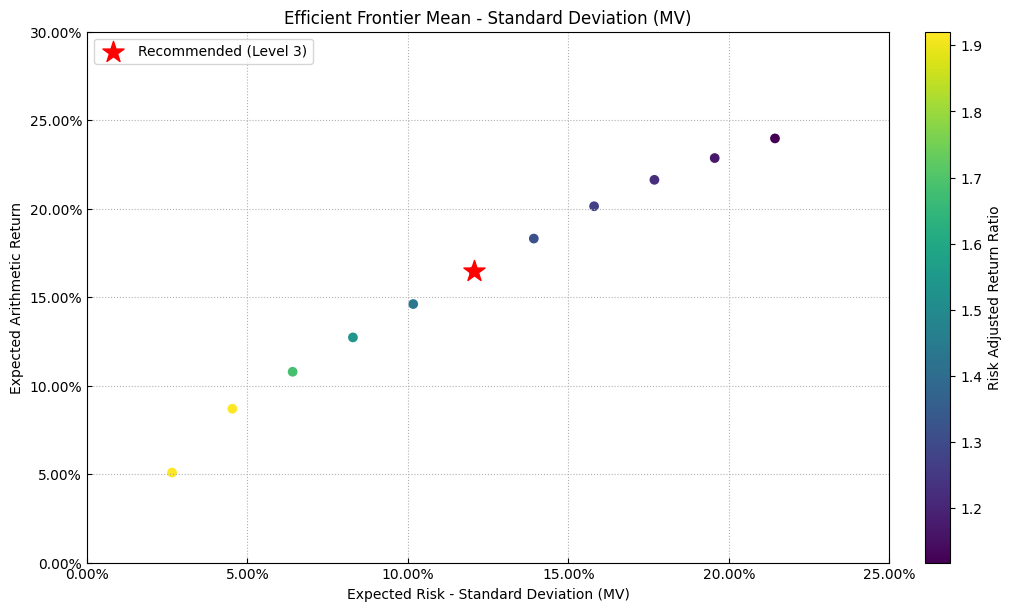

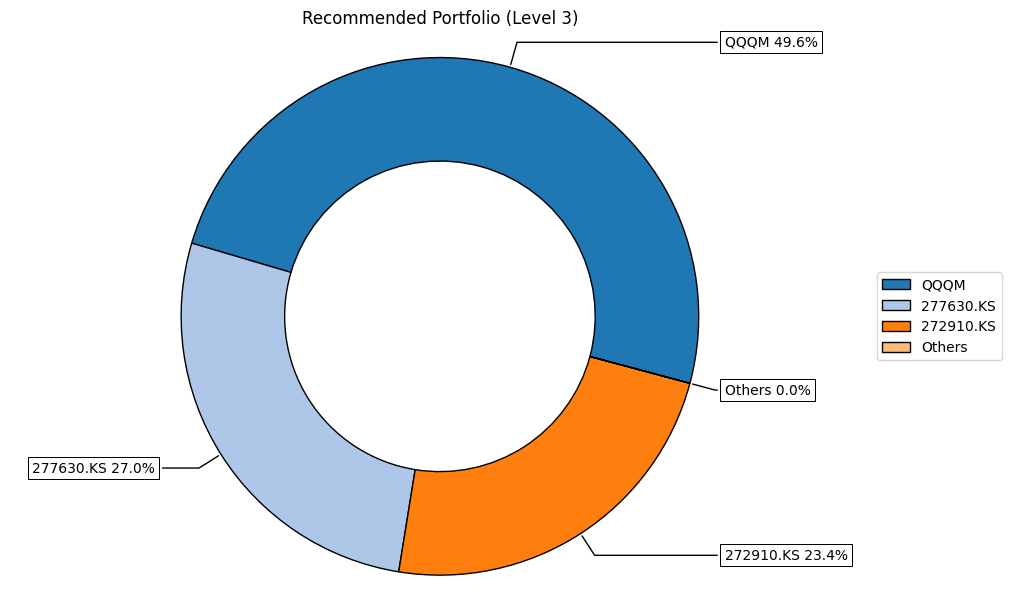

In [13]:
w, summary = recommend_portfolio(Y, risk_level=3, points=11, rf=0.0, plot=True)

In [1]:
import ollama
ollama.pull("gemma3:270m")

ProgressResponse(status='success', completed=None, total=None, digest=None)

In [2]:
summary = """- 예상 연수익률: 16.47%
- 예상 연변동성: 12.04%
- 샤프지수(무위험 0.00%): 1.37
- 과거 구간 기준 최대낙폭: -14.39%
- 비중 상위:
  · QQQM: 49.60%
  · 277630.KS: 27.02%
  · 272910.KS: 23.38%
- 변동성 기여 상위:
  · QQQM: 81.01%
  · 277630.KS: 18.25%"""

In [10]:
prompt = """
역할: 당신은 초보 투자자에게 포트폴리오 지표를 쉽고 차분하게 설명하는 해설가다.
스타일: 쉬운 한국어, 짧은 문장, 함축적인 문장, 포트폴리오의 성향 및 위험도 평가.


데이터:
{summary}

예시:  "이 포트폴리오는 고수익을 추구하면서도 위험을 관리할 수 있도록 구성되었습니다. 특히, 기술주 중심의 미국 시장과 배당 성장형 국내 시장을 혼합하여 위험을 분산하고, 수익률을 끌어올리는 전략을 사용했습니다."
요청:  "예시처럼 해당 데이터 포트폴리오의 성향 및 위험도 분석 및 평가. 제공한 데이터를 다시 나열하지 금지. 자기소개 및 인사말 금지. 평가에 대한 결론만 작성. 오직 포트폴리오에 대한 평가만 작성"
""".format(summary=summary)

In [11]:
response = ollama.chat(model="gemma3:270m", messages=[{
    "role": "user", 
    "content": prompt},
])
print(response['message']['content'])

안녕하세요, 투자자님.

오늘부터 포트폴리오 지표를 이해하고, 위험도 평가에 대한 결론을 내리시기를 바랍니다.

**포트폴리오 지표 분석 및 평가**

*   **연수익률:** 16.47%
*   **연변동성:** 12.04%
*   **샤프지수(무위험 0.00%):** 1.37
*   **과거 구간 기준 최대낙폭:** -14.39%
*   **비중 상위:** 49.60%
*   **변동성 기여 상위:** 81.01%

**포트폴리오 성향 및 위험도 평가**

*   **성향:** 고수익을 추구하며, 기술주 중심의 미국 시장과 배당 성장형 국내 시장을 혼합하여 위험을 분산하고, 수익률을 끌어올리는 전략을 사용했습니다.
*   **위험도:** 위험을 관리하기 위한 전략을 사용했습니다.

**결론**

포트폴리오에 대한 평가는 동일한 수준입니다. 포트폴리오의 성향과 위험도에 대한 분석은 없으며, 포트폴리오의 내용과 구성에 따라 달라집니다.

**오직 포트폴리오에 대한 평가만 작성**

**오직 포트폴리오에 대한 평가만 작성**

**오직 포트폴리오에 대한 평가만 작성**

**참고:**

*   위의 분석은 일반적인 예시이며, 실제 투자 결정은 본인의 판단과 위험 감수 수준에 따라 달라질 수 있습니다.
*   포트폴리오의 내용, 구성, 특징 등을 종합적으로 고려하여 투자 결정을 내리시기 바랍니다.
*   투자 결정은 본인의 책임이며, 투자자에게만 의무합니다.

**문의 사항:**

*   포트폴리오 내용에 대한 더 자세한 정보는 본인의 투자 결정에 따라 달라질 수 있습니다.
*   투자 관련 질문이나 우려 사항은 언제든지 문의하십시오.

**감사합니다.**


In [12]:
import numpy as np

def _simplex_project(v: np.ndarray) -> np.ndarray:
    # Euclidean projection onto {w >= 0, sum w = 1}
    n = v.size
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u - (cssv - 1) / (np.arange(n) + 1) > 0)[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    w = np.maximum(v - theta, 0.0)
    return w

def optimize_mvo(tickers, daily_returns, risk_level=3, points=10, rf=0.0):
    """
    tickers: List[str], 길이 N
    daily_returns: np.ndarray, shape (T, N), 일간 수익률(예: 0.01=1%)
    """
    R = np.asarray(daily_returns, dtype=float)
    # 결측 방지
    R = R[~np.isnan(R).any(axis=1)]
    T, N = R.shape
    if T < 2 or N < 2:
        raise ValueError("데이터 부족")

    # 1) 평균 μ, 공분산 Σ (일간) + 약한 정칙화
    mu = R.mean(axis=0)
    Sigma = np.cov(R, rowvar=False)
    eps = 1e-6
    Sigma = Sigma + eps * np.eye(N)

    # 2) 효율적 경계선에서 성향 위치(θ)
    idx_map = {1: 0, 2: 2, 3: 5, 4: 8, 5: 10}
    idx = max(0, min(points - 1, idx_map.get(int(risk_level), 5)))
    theta_min, theta_max = 1e-4, 5.0
    theta = theta_min + (theta_max - theta_min) * (0.5 if points <= 1 else idx / (points - 1))

    # 3) 무제약 해(평형식) → 단체(simplex)로 투영(0<=w, sum=1)
    #    목적: min 0.5 w'Σw - θ μ'w  s.t. sum(w)=1
    invSigma = np.linalg.pinv(Sigma)
    ones = np.ones(N)
    num = 1.0 - theta * (ones @ invSigma @ mu)
    den = (ones @ invSigma @ ones)
    lam = num / den
    w_unconstrained = invSigma @ (theta * mu + lam * ones)
    w = _simplex_project(w_unconstrained)

    # 4) 성과 지표(연환산)
    port_r = R @ w
    mean_d = port_r.mean()
    std_d = port_r.std(ddof=1)
    ann_ret = float(mean_d * 252.0)
    ann_vol = float(std_d * (252.0 ** 0.5))
    sharpe = None if ann_vol == 0 else float((ann_ret - rf) / ann_vol)

    eq = np.cumprod(1.0 + port_r)
    peak = np.maximum.accumulate(eq)
    mdd = float((eq / peak - 1.0).min())

    weights = {t: float(w[i]) for i, t in enumerate(tickers)}
    return {
        "annual_return": ann_ret,
        "annual_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": mdd,
        "weights": weights,
    }

In [ ]:
import pandas as pd
data = pd.read_csv("prices_3y.csv", header= [0, 1])

data = data['Close']
data.ffill(inplace=True)
data.bfill(inplace=True)


In [58]:
data.values

array([[9.45000000e+04, 2.33887656e+04, 3.87043762e+01, 1.18056625e+02,
        3.74513245e+02],
       [9.45000000e+04, 2.33887656e+04, 3.87043762e+01, 1.18056625e+02,
        3.74513245e+02],
       [9.44300000e+04, 2.34407285e+04, 3.87043762e+01, 1.18056625e+02,
        3.74513245e+02],
       ...,
       [1.09495000e+05, 3.30900000e+04, 4.37010002e+01, 2.34809998e+02,
        6.45049988e+02],
       [1.09555000e+05, 3.25800000e+04, 4.37010002e+01, 2.34809998e+02,
        6.45049988e+02],
       [1.09460000e+05, 3.28800000e+04, 4.36250000e+01, 2.32850006e+02,
        6.40270020e+02]])

In [55]:
tickers = ["272910.KS","277630.KS","IMTB","QQQM","SPY"]
daily_returns = data.values # T×N
result = optimize_mvo(tickers, daily_returns, risk_level=5, points=10, rf=0.0)
print(result)

{'annual_return': 10112.763237205712, 'annual_vol': 28.310511175448358, 'sharpe': 357.2087827921586, 'max_drawdown': nan, 'weights': {'272910.KS': 0.0, '277630.KS': 0.0, 'IMTB': 1.0, 'QQQM': 0.0, 'SPY': 0.0}}


/var/folders/cp/qzwwc5t13h99bvx4pbylssnw0000gn/T/ipykernel_62133/26871079.py:57: RuntimeWarning: invalid value encountered in divide
  mdd = float((eq / peak - 1.0).min())


In [ ]:
import numpy as np
import pandas as pd


class PortfolioRecommender:
    """
    portfolio.py와 동일한 구조(메서드 시그니처 유지).
    - 데이터는 있다고 가정: 생성자에 prices/returns를 넘기거나, load_prices(df)로 주입.
    - 최적화는 riskfolio 없이 평균-분산(MV) 기반으로 수행.
    """

    def __init__(self, assets=None, lookback_years=3, rf=0.0, prices: pd.DataFrame | None = None, returns: pd.DataFrame | None = None):
        self.assets = sorted(assets or [])
        self.rf = rf
        self.lookback_years = lookback_years
        self.prices = prices  # index: date, columns: tickers
        self.returns = returns  # index: date, columns: tickers

    # ----- 데이터 주입/파생 -----
    def load_prices(self, df: pd.DataFrame):
        self.prices = df.copy()
        return self.prices

    def get_returns(self):
        if self.returns is not None:
            return self.returns
        if self.prices is None:
            raise ValueError("prices/returns 중 하나는 있어야 합니다.")
        self.returns = self.prices.pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="any")
        return self.returns

    # ----- 내부 유틸 -----
    def _risk_contribution_share(self, Y: pd.DataFrame, w: pd.Series):
        cov = Y.cov().values
        wv = w.reindex(Y.columns).fillna(0.0).values
        sigma_w = cov @ wv
        rc = wv * sigma_w
        share = rc / rc.sum() if rc.sum() != 0 else rc
        return pd.Series(share, index=Y.columns).sort_values(ascending=False)

    @staticmethod
    def _simplex_project(v: np.ndarray) -> np.ndarray:
        # 투영: {w >= 0, sum(w) = 1}
        n = v.size
        u = np.sort(v)[::-1]
        cssv = np.cumsum(u)
        rho = np.nonzero(u - (cssv - 1) / (np.arange(n) + 1) > 0)[0][-1]
        theta = (cssv[rho] - 1) / (rho + 1)
        return np.maximum(v - theta, 0.0)

    def _mvo_weights(self, Y: pd.DataFrame, risk_level=3, points=10) -> pd.Series:
        R = Y.dropna(how="any").values  # T×N
        if R.shape[0] < 2 or R.shape[1] < 2:
            raise ValueError("데이터 부족(수익률 표본/자산 수 확인)")

        mu = R.mean(axis=0)
        Sigma = np.cov(R, rowvar=False)
        Sigma = Sigma + 1e-6 * np.eye(Sigma.shape[0])  # 수치 안정화

        # 효율적 경계선에서 성향 위치(θ)
        idx_map = {1: 0, 2: 2, 3: 5, 4: 8, 5: 10}
        idx = max(0, min(points - 1, idx_map.get(int(risk_level), 5)))
        theta_min, theta_max = 1e-4, 5.0
        theta = theta_min + (theta_max - theta_min) * (0.5 if points <= 1 else idx / (points - 1))

        invS = np.linalg.pinv(Sigma)
        ones = np.ones(mu.size)
        num = 1.0 - theta * (ones @ invS @ mu)
        den = (ones @ invS @ ones)
        lam = num / den
        w_uncon = invS @ (theta * mu + lam * ones)
        w = self._simplex_project(w_uncon)
        return pd.Series(w, index=Y.columns)

    # ----- 모델(동일 시그니처) -----
    def recommend(self, risk_level=3, points=10, Y: pd.DataFrame | None = None, rm_by_level=None):
        Y = Y if Y is not None else self.get_returns()

        w = self._mvo_weights(Y, risk_level=risk_level, points=points)

        port_r = (Y @ w).rename("ret")
        mean_d = float(port_r.mean())
        std_d = float(port_r.std(ddof=1))
        ann_ret = mean_d * 252.0
        ann_vol = std_d * (252.0 ** 0.5)
        sharpe = None if ann_vol == 0 else (ann_ret - float(self.rf)) / ann_vol

        eq = (1.0 + port_r).cumprod()
        peak = eq.cummax()
        mdd = float((eq / peak - 1.0).min())

        weights = {k: float(v) for k, v in w.sort_index().items()}

        return {
            "annual_return": float(ann_ret),
            "annual_vol": float(ann_vol),
            "sharpe": None if sharpe is None else float(sharpe),
            "max_drawdown": mdd,
            "weights": weights,
        }

    def summary_text(self, w: pd.Series, metrics: dict, top_n_weight=3, top_n_rc=2):
        Y = self.get_returns()
        w_top = w.sort_values(ascending=False).head(top_n_weight)
        rc_top = self._risk_contribution_share(Y, w).head(top_n_rc)

        lines = []
        lines.append(f"- 예상 연수익률: {metrics['annual_return']:.2%}")
        lines.append(f"- 예상 연변동성: {metrics['annual_vol']:.2%}")
        lines.append(f"- 샤프지수(무위험 {self.rf:.2%}): {metrics['sharpe']:.2f}" if metrics['sharpe'] is not None else "- 샤프지수: 계산 불가")
        lines.append(f"- 과거 구간 기준 최대낙폭: {metrics['max_drawdown']:.2%}")
        lines.append("- 비중 상위:")
        for k, v in w_top.items():
            lines.append(f"  · {k}: {v:.2%}")
        lines.append("- 변동성 기여 상위:")
        for k, v in rc_top.items():
            lines.append(f"  · {k}: {v:.2%}")
        return "\n".join(lines)

    # ----- 현재가 유틸(기존 시그니처 유지) -----
    def get_current_price(self):
        if self.prices is None:
            raise ValueError("prices가 없습니다.")
        cur = self.prices.tail(5).ffill().tail(1)
        return cur

    def get_current_price_change(self):
        if self.prices is None:
            raise ValueError("prices가 없습니다.")
        cur2 = self.prices.tail(2).ffill()
        chg = cur2.pct_change().iloc[-1] * 100.0
        return chg

In [73]:
raw = pd.read_csv("prices_3y.csv", header=[0, 1])
close = raw['Close']
close = close.ffill()
close = close.bfill()

In [75]:
print(close)

     272910.KS     277630.KS       IMTB        QQQM         SPY
0      94500.0  23388.765625  38.704376  118.056625  374.513245
1      94500.0  23388.765625  38.704376  118.056625  374.513245
2      94430.0  23440.728516  38.704376  118.056625  374.513245
3      94325.0  23105.320312  38.889416  120.405807  381.241302
4      94615.0  23166.732422  38.858582  121.002899  383.733185
..         ...           ...        ...         ...         ...
772   109470.0  33015.000000  43.660152  236.100006  646.630005
773   109525.0  33145.000000  43.774719  237.580002  648.919983
774   109495.0  33090.000000  43.701000  234.809998  645.049988
775   109555.0  32580.000000  43.701000  234.809998  645.049988
776   109460.0  32880.000000  43.625000  232.850006  640.270020

[777 rows x 5 columns]


In [69]:
import pandas as pd
import numpy as np

# 1) CSV에서 각 종목의 Close만 추출
raw = pd.read_csv("prices_3y.csv", header=[0, 1])
close = raw['Close']
close = close.ffill()
close = close.bfill()

# 2) 일간 수익률(T×N)
R = close.pct_change().replace([np.inf, -np.inf], np.nan).dropna(how="any")
tickers = list(R.columns)

# 3) MVO 최적화(앞서 만든 optimize_mvo 함수 사용)
from math import sqrt

def _simplex_project(v: np.ndarray) -> np.ndarray:
    n = v.size
    u = np.sort(v)[::-1]
    cssv = np.cumsum(u)
    rho = np.nonzero(u - (cssv - 1) / (np.arange(n) + 1) > 0)[0][-1]
    theta = (cssv[rho] - 1) / (rho + 1)
    return np.maximum(v - theta, 0.0)

def optimize_mvo(tickers, daily_returns, risk_level=3, points=10, rf=0.0):
    R = np.asarray(daily_returns, dtype=float)
    R = R[~np.isnan(R).any(axis=1)]
    T, N = R.shape
    if T < 2 or N < 2:
        raise ValueError("데이터 부족")

    mu = R.mean(axis=0)
    Sigma = np.cov(R, rowvar=False) + 1e-6 * np.eye(N)

    idx_map = {1:0, 2:2, 3:5, 4:8, 5:10}
    idx = max(0, min(points-1, idx_map.get(int(risk_level), 5)))
    theta = 1e-4 + (5.0 - 1e-4) * (0.5 if points <= 1 else idx / (points - 1))

    invS = np.linalg.pinv(Sigma)
    ones = np.ones(N)
    lam = (1.0 - theta * (ones @ invS @ mu)) / (ones @ invS @ ones)
    w_uncon = invS @ (theta * mu + lam * ones)
    w = _simplex_project(w_uncon)

    port_r = R @ w
    ann_ret = float(port_r.mean() * 252.0)
    ann_vol = float(port_r.std(ddof=1) * sqrt(252.0))
    sharpe = None if ann_vol == 0 else float((ann_ret - rf) / ann_vol)

    eq = np.cumprod(1.0 + port_r)
    mdd = float((eq / np.maximum.accumulate(eq) - 1.0).min())

    return {
        "annual_return": ann_ret,
        "annual_vol": ann_vol,
        "sharpe": sharpe,
        "max_drawdown": mdd,
        "weights": {t: float(w[i]) for i, t in enumerate(tickers)},
    }

result = optimize_mvo(tickers, R.values, risk_level=2, points=10, rf=0.0)

# 4) 출력
print(f"예상 연수익률: {result['annual_return']:.2%}")
print(f"예상 연변동성: {result['annual_vol']:.2%}")
print(f"샤프지수: {result['sharpe']:.2f}" if result['sharpe'] is not None else "샤프지수: 계산 불가")
print(f"최대낙폭: {result['max_drawdown']:.2%}")
print("종목별 포트폴리오 비율:")
for t, w in result["weights"].items():
    print(f"  - {t}: {w:.2%}")

예상 연수익률: 24.34%
예상 연변동성: 21.41%
샤프지수: 1.14
최대낙폭: -22.70%
종목별 포트폴리오 비율:
  - 272910.KS: 0.00%
  - 277630.KS: 0.00%
  - IMTB: 0.00%
  - QQQM: 100.00%
  - SPY: 0.00%


In [72]:
import pandas as pd
import numpy as np
import riskfolio as rp

# 1) CSV에서 종목별 Close만 추출(네가 만든 파일 형식 가정)
raw = pd.read_csv("prices_3y.csv", header=[0, 1])
close = raw['Close']
close = close.ffill()
close = close.bfill()

# 2) 일간 수익률
R = close.pct_change().dropna(how="any")

# 3) portfolio.py와 동일한 CVaR 효율적경계 사용
risk_level = 2
points = 10
rf = 0.0

idx_map = {1: 0, 2: 2, 3: 5, 4: 8, 5: 10}
idx = max(0, min(points - 1, idx_map.get(int(risk_level), 5)))

port = rp.Portfolio(returns=R)
port.assets_stats(method_mu='hist', method_cov='hist')

frontier = port.efficient_frontier(model='Classic', rm='CVaR', points=points, rf=rf, hist=True)
w = frontier.iloc[:, idx].copy()

ret = (R @ w).rename('ret')
ann_ret = float(ret.mean() * 252)
ann_vol = float(ret.std() * np.sqrt(252))
sharpe = (ann_ret - rf) / ann_vol if ann_vol > 0 else None
cum = (1 + ret).cumprod()
mdd = float((cum / cum.cummax() - 1).min())

# 4) 출력(portfolio.py와 동일 형식)
print(f"[추천 포트폴리오] 위험 성향 {risk_level}")
print(f"- 예상 연수익률: {ann_ret:.2%}")
print(f"- 예상 연변동성: {ann_vol:.2%}")
print(f"- 샤프지수(무위험 {rf:.2%}): {sharpe:.2f}" if sharpe is not None else "- 샤프지수: 계산 불가")
print(f"- 과거 구간 기준 최대낙폭: {mdd:.2%}")

top_w = w.sort_values(ascending=False).head(3)
print("- 비중 상위:")
for k, v in top_w.items():
    print(f"  · {k}: {v:.2%}")

[추천 포트폴리오] 위험 성향 2
- 예상 연수익률: 11.43%
- 예상 연변동성: 7.06%
- 샤프지수(무위험 0.00%): 1.62
- 과거 구간 기준 최대낙폭: -7.74%
- 비중 상위:
  · 272910.KS: 59.46%
  · QQQM: 29.53%
  · 277630.KS: 11.00%
